**Importing the libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import folium
import joblib
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


In [2]:
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
!pip install keras --upgrade

**Importing the dataset**

In [17]:
data = pd.read_csv('Sales2.csv')
data['Date'] = pd.to_datetime(data['Date'])
data.head()

,Date,Order,Item Purchased,Sales,Review Rating,Shipping Type,Discount Applied,Promo Code Used
0,2023-01-01,3164576526,Skirt,2,3.1,Express,Yes,Yes
1,2023-01-02,3165351216,Shirt,2,3.1,Express,Yes,Yes
2,2023-01-02,12-10986-29949,Blouse,4,3.1,Free Shipping,Yes,Yes
3,2023-01-02,3166515488,Shirt,5,3.5,Next Day Air,Yes,Yes
4,2023-01-02,3166572296-1,Shirt,2,2.7,Free Shipping,Yes,Yes


In [ ]:
data.shape

(1653, 8)

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1653 entries, 0 to 1652
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              1653 non-null   datetime64[ns]
 1   Item Purchased    1653 non-null   int64         
 2   Sales             1653 non-null   int64         
 3   Review Rating     1653 non-null   float64       
 4   Shipping Type     1653 non-null   int64         
 5   Discount Applied  1653 non-null   int64         
 6   Promo Code Used   1653 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(5)
memory usage: 90.5 KB


In [ ]:
data.describe()

,Date,Sales,Review Rating
count,1653,1653.000000,1653.000000
mean,2023-02-05 18:11:32.558983680,2.980641,3.742589
min,2023-01-01 00:00:00,1.000000,2.500000
25%,2023-01-11 00:00:00,2.000000,3.100000
50%,2023-01-27 00:00:00,3.000000,3.700000
75%,2023-02-19 00:00:00,4.000000,4.400000
max,2023-05-03 00:00:00,5.000000,5.000000
std,NaN,1.389031,0.717729


In [ ]:
data.columns

Index(['Date', 'Order', 'Item Purchased', 'Sales', 'Review Rating',
       'Shipping Type', 'Discount Applied', 'Promo Code Used'],
      dtype='object')

In [ ]:
# Identify the data types of columns
column_data_types = data.dtypes

# Count the numerical and categorical columns
numerical_count = 0
categorical_count = 0

for column_name, data_type in column_data_types.items():
    if np.issubdtype(data_type, np.number):
        numerical_count += 1
    else:
        categorical_count += 1

# Print the counts
print(f"There are {numerical_count} Numerical Columns in dataset")
print(f"There are {categorical_count} Categorical Columns in dataset")

There are 2 Numerical Columns in dataset
There are 6 Categorical Columns in dataset


In [ ]:
#Random Sample of dataset with only categorical Feature
data.select_dtypes(include='O').sample(5)

,Order,Item Purchased,Shipping Type,Discount Applied,Promo Code Used
1647,3285886407,Skirt,Store Pickup,Yes,Yes
29,3157980131,Shirt,Store Pickup,Yes,Yes
872,26-11090-39314,Blouse,Standard,Yes,Yes
55,22-10982-43713,Blouse,2-Day Shipping,Yes,Yes
1429,3249173311,Shirt,Standard,Yes,Yes


In [18]:
#Labelling of Categories in Numerical Features.
data["Item Purchased"] = data["Item Purchased"].replace({"Shirt":1,"Blouse":2,"Skirt":3,"Dress":4})
data["Shipping Type"] = data["Shipping Type"].replace({"2-Day Shipping":1,"Standard":2,"Store Pickup":3,"Express":4,"Free Shipping":5,"Next Day Air":6})
data["Promo Code Used"] = data["Promo Code Used"].replace({"Yes":0,"No":1})
data["Discount Applied"] = data["Discount Applied"].replace({"Yes":0,"No":1})

In [19]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [20]:
Item_le=LabelEncoder()
ShippingType_le=LabelEncoder()
Discount_le=LabelEncoder()
Promocode_le=LabelEncoder()

In [21]:
data['Item Purchased'] = Item_le.fit_transform(data['Item Purchased'])
data['Shipping Type'] = ShippingType_le.fit_transform(data['Shipping Type'])
data['Discount Applied'] = Discount_le.fit_transform(data['Discount Applied'])
data['Promo Code Used'] = Promocode_le.fit_transform(data['Promo Code Used'])

In [22]:
data.drop('Order', axis=1, inplace=True)

In [9]:
data.head()

,Date,Item Purchased,Sales,Review Rating,Shipping Type,Discount Applied,Promo Code Used
0,2023-01-01,2,2,3.1,3,0,0
1,2023-01-02,0,2,3.1,3,0,0
2,2023-01-02,1,4,3.1,4,0,0
3,2023-01-02,0,5,3.5,5,0,0
4,2023-01-02,0,2,2.7,4,0,0


In [23]:
#Checking if There's Any Duplicate Records.
print("Duplicates in Dataset: ",data.duplicated().sum())
data= data.drop_duplicates()
data

Duplicates in Dataset:  27


,Date,Item Purchased,Sales,Review Rating,Shipping Type,Discount Applied,Promo Code Used
0,2023-01-01,2,2,3.1,3,0,0
1,2023-01-02,0,2,3.1,3,0,0
2,2023-01-02,1,4,3.1,4,0,0
3,2023-01-02,0,5,3.5,5,0,0
4,2023-01-02,0,2,2.7,4,0,0
...,...,...,...,...,...,...,...
1648,2023-05-03,2,3,2.6,3,0,0
1649,2023-05-03,2,1,4.9,4,0,0
1650,2023-05-03,2,1,3.4,5,0,0
1651,2023-05-03,2,2,3.9,1,0,0


In [24]:
#Computing Total No. of Missing Values and the Percentage of Missing Values.
missing_data = data.isnull().sum().to_frame().rename(columns={0:"Total No. of Missing Values"})
missing_data["% of Missing Values"] = round((missing_data["Total No. of Missing Values"]/len(data))*100,2)
missing_data

,Total No. of Missing Values,% of Missing Values
Date,0,0.0
Item Purchased,0,0.0
Sales,0,0.0
Review Rating,0,0.0
Shipping Type,0,0.0
Discount Applied,0,0.0
Promo Code Used,0,0.0


In [25]:
#Checking Unique Values of Categorical Attributes.
cat_cols = data.select_dtypes(include="O").columns

for column in cat_cols:
    print('Unique values of ', column, set(data[column]))
    print("-"*121)

In [26]:
data['Date'] = pd.to_datetime(data['Date'], format='%Y-%m-%d', errors='coerce')
print("Data after conversion:")
print(data)

Data after conversion:
           Date  Item Purchased  Sales  Review Rating  Shipping Type  \
0    2023-01-01               2      2            3.1              3   
1    2023-01-02               0      2            3.1              3   
2    2023-01-02               1      4            3.1              4   
3    2023-01-02               0      5            3.5              5   
4    2023-01-02               0      2            2.7              4   
...         ...             ...    ...            ...            ...   
1648 2023-05-03               2      3            2.6              3   
1649 2023-05-03               2      1            4.9              4   
1650 2023-05-03               2      1            3.4              5   
1651 2023-05-03               2      2            3.9              1   
1652 2023-05-03               2      2            4.0              5   

      Discount Applied  Promo Code Used  
0                    0                0  
1                    0      

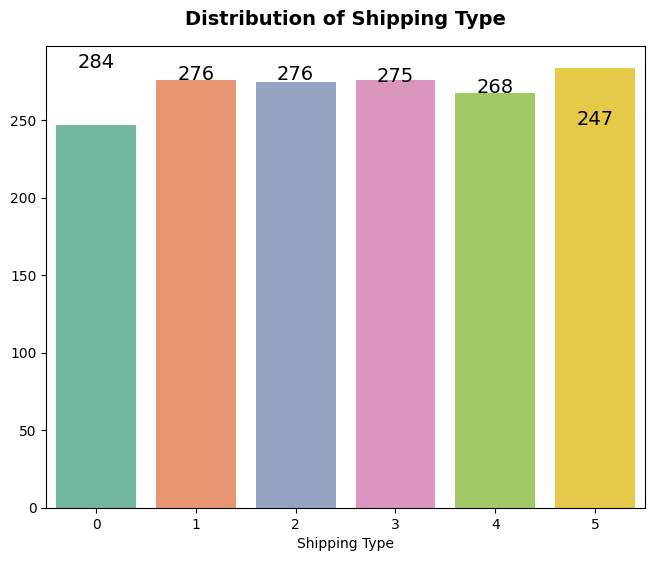

In [27]:
plt.figure(figsize=(17,6))
plt.subplot(1,2,1)
df_plot = data.groupby('Sales')['Shipping Type'].sum().to_frame()
df_plot = df_plot.sort_values('Sales', ascending = False)
attrition_rate = data["Shipping Type"].value_counts()
sns.barplot(x=attrition_rate.index,y=attrition_rate.values,palette= 'Set2')
plt.title("Distribution of Shipping Type",fontweight="black", size=14, pad=15)
for i, v in enumerate(attrition_rate.values):
    plt.text(i, v, v,ha="center", fontsize=14)

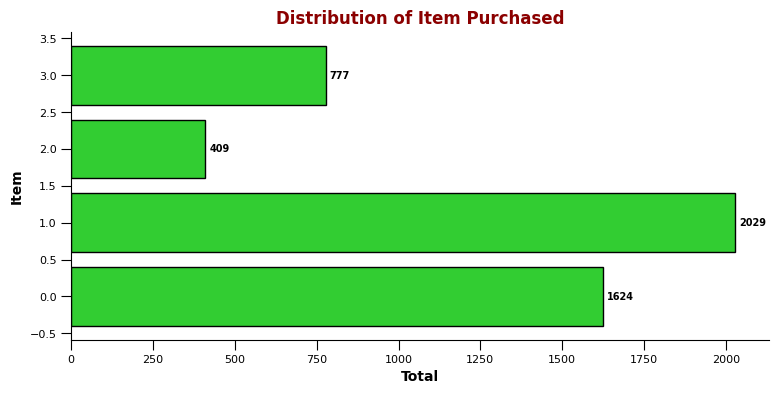

In [28]:
df_plot = data.groupby('Item Purchased')['Sales'].sum().to_frame()
df_plot = df_plot.sort_values('Sales', ascending = False)

fig,ax = plt.subplots(figsize=(9,4))
rects1 = ax.barh(df_plot.index, df_plot.iloc[:,0], linewidth = 1.,
                 edgecolor = 'black', color = '#32CD32')
ax.tick_params(labelsize=8, size=7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Distribution of Item Purchased', fontsize = 12, fontweight = 'bold', color = 'darkred')
ax.set_xlabel('Total', fontsize = 10, fontweight = 'bold', color = 'black')
ax.set_ylabel('Item', fontsize = 10, fontweight = 'bold', color = 'black')
def autolabel(rects):

  for rect in rects:
      width = rect.get_width()
      height = rect.get_height()
      ax.annotate('{}'.format(width),
                  xy=(width, rect.get_y() + rect.get_height() / 2),
                  xytext=(3,0),
                  textcoords="offset points",
                  ha='left', va='center', size = 7, weight = 'bold')

autolabel(rects1)
fig.show()

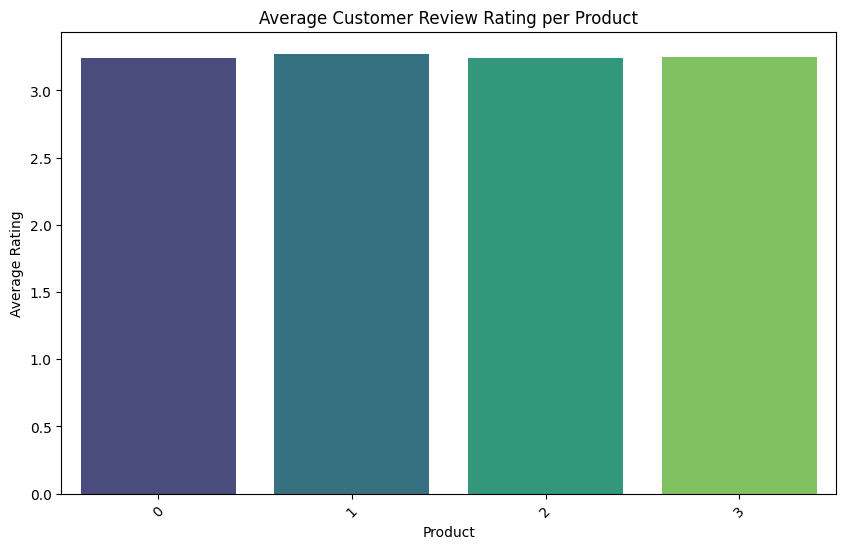

In [29]:
data['Review Rating'] = data['Review Rating'].astype(int)

# Tính toán đánh giá trung bình cho mỗi sản phẩm
average_ratings = data.groupby('Item Purchased')['Review Rating'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Item Purchased', y='Review Rating', data=average_ratings, palette='viridis')
plt.title('Average Customer Review Rating per Product')
plt.xlabel('Product')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

In [35]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=['Sales','Date'])
y = data['Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
X

,Item Purchased,Review Rating,Shipping Type,Discount Applied,Promo Code Used
0,2,3,3,0,0
1,0,3,3,0,0
2,1,3,4,0,0
3,0,3,5,0,0
4,0,2,4,0,0
...,...,...,...,...,...
1648,2,2,3,0,0
1649,2,4,4,0,0
1650,2,3,5,0,0
1651,2,3,1,0,0


**Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred

In [ ]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

# Hiển thị kết quả dự đoán và thực tế
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results)

Mean Squared Error: 0.11517387403509738
Mean Absolute Error: 0.28714297983877035
            Actual  Predicted
Date                         
2023-01-08    0.00   0.494224
2023-01-02    0.75   0.464008
2023-01-16    1.00   0.483608
2023-01-13    0.75   0.498153
2023-01-02    1.00   0.511765
...            ...        ...
2023-01-05    0.25   0.516445
2023-01-15    0.50   0.484590
2023-02-11    0.50   0.508884
2023-01-16    0.25   0.510253
2023-03-07    0.25   0.512608

[331 rows x 2 columns]


In [ ]:
# Vẽ biểu đồ phân tán giữa giá trị dự đoán và giá trị thực
plt.figure(figsize=(12, 10))
plt.scatter(y_pred, y_test, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r-', lw=2)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Scatter Plot of Predicted vs Actual Values')
plt.show()

**KNeighbors Classifier**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# Khởi tạo mô hình hồi quy K-Nearest Neighbors
model = KNeighborsRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred

array([0.65, 0.7 , 0.8 , 0.55, 0.5 , 0.5 , 0.35, 0.25, 0.45, 0.45, 0.2 ,
       0.4 , 0.6 , 0.55, 0.7 , 0.55, 0.35, 0.4 , 0.8 , 0.55, 0.5 , 0.5 ,
       0.55, 0.55, 0.5 , 0.6 , 0.45, 0.7 , 0.5 , 0.35, 0.55, 0.5 , 0.1 ,
       0.4 , 0.45, 0.55, 0.55, 0.45, 0.6 , 0.5 , 0.85, 0.3 , 0.6 , 0.35,
       0.45, 0.6 , 0.35, 0.35, 0.6 , 0.25, 0.3 , 0.55, 0.5 , 0.65, 0.35,
       0.3 , 0.2 , 0.4 , 0.35, 0.75, 0.35, 0.5 , 0.65, 0.5 , 0.5 , 0.4 ,
       0.55, 0.45, 0.65, 0.35, 0.65, 0.35, 0.65, 0.35, 0.45, 0.3 , 0.6 ,
       0.5 , 0.45, 0.45, 0.65, 0.3 , 0.6 , 0.4 , 0.95, 0.8 , 0.45, 0.25,
       0.2 , 0.25, 0.45, 0.3 , 0.4 , 0.6 , 0.5 , 0.55, 0.5 , 0.75, 0.45,
       0.3 , 0.4 , 0.45, 0.5 , 0.55, 0.35, 0.5 , 0.5 , 0.5 , 0.35, 0.55,
       0.35, 0.8 , 0.45, 0.45, 0.35, 0.25, 0.35, 0.45, 0.45, 0.65, 0.2 ,
       0.4 , 0.45, 0.15, 0.65, 0.45, 0.5 , 0.6 , 0.45, 0.45, 0.45, 0.45,
       0.6 , 0.5 , 0.35, 0.35, 0.7 , 0.45, 0.25, 0.55, 0.45, 0.45, 0.3 ,
       0.7 , 0.55, 0.6 , 0.25, 0.65, 0.75, 0.6 , 0.

In [ ]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

# Hiển thị kết quả dự đoán và thực tế
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results)

Mean Squared Error: 0.1524395770392749
Mean Absolute Error: 0.3246223564954683
            Actual  Predicted
Date                         
2023-01-08    0.00       0.65
2023-01-02    0.75       0.70
2023-01-16    1.00       0.80
2023-01-13    0.75       0.55
2023-01-02    1.00       0.50
...            ...        ...
2023-01-05    0.25       0.40
2023-01-15    0.50       0.60
2023-02-11    0.50       0.70
2023-01-16    0.25       0.30
2023-03-07    0.25       0.80

[331 rows x 2 columns]


**GradientBoostingClassifier**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Khởi tạo mô hình Gradient Boosting dành cho hồi quy
model = GradientBoostingRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred

array([0.54827345, 0.59950006, 0.6419434 , 0.53153509, 0.62177931,
       0.51085916, 0.49811714, 0.504018  , 0.49159741, 0.51357502,
       0.41703487, 0.51328551, 0.47075843, 0.6636289 , 0.52005584,
       0.49542743, 0.47428528, 0.5036639 , 0.50882737, 0.50497913,
       0.52560963, 0.45587867, 0.4691043 , 0.51815427, 0.39882237,
       0.51479005, 0.345442  , 0.74466446, 0.4385497 , 0.49571621,
       0.46424361, 0.41332015, 0.43017987, 0.50497806, 0.46630687,
       0.4351361 , 0.43415605, 0.51303126, 0.49250271, 0.52326335,
       0.52217709, 0.51929246, 0.50316089, 0.48892478, 0.49172971,
       0.63016546, 0.40528635, 0.50077468, 0.59854622, 0.48574252,
       0.49832828, 0.48287049, 0.48701876, 0.56004954, 0.48696176,
       0.45205567, 0.3815967 , 0.48762153, 0.48003514, 0.76844048,
       0.32993282, 0.49987007, 0.55336995, 0.52373711, 0.58019835,
       0.59076753, 0.63621712, 0.61629872, 0.52348195, 0.56504257,
       0.58540126, 0.43591095, 0.63820593, 0.36761218, 0.49908

In [ ]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

# Hiển thị kết quả dự đoán và thực tế
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results)

Mean Squared Error: 0.12485040852928717
Mean Absolute Error: 0.3004034433028654
            Actual  Predicted
Date                         
2023-01-08    0.00   0.548273
2023-01-02    0.75   0.599500
2023-01-16    1.00   0.641943
2023-01-13    0.75   0.531535
2023-01-02    1.00   0.621779
...            ...        ...
2023-01-05    0.25   0.392024
2023-01-15    0.50   0.485804
2023-02-11    0.50   0.612849
2023-01-16    0.25   0.363675
2023-03-07    0.25   0.587714

[331 rows x 2 columns]


**Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Khởi tạo mô hình Random Forest dành cho hồi quy
model = RandomForestRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred

array([0.625 , 0.5775, 0.5475, 0.81  , 0.665 , 0.3975, 0.415 , 0.5175,
       0.62  , 0.76  , 0.485 , 0.72  , 0.5925, 0.395 , 0.71  , 0.4175,
       0.5225, 0.6975, 0.3975, 0.5525, 0.48  , 0.675 , 0.4075, 0.6775,
       0.4475, 0.6225, 0.3575, 0.7775, 0.395 , 0.625 , 0.3575, 0.2125,
       0.45  , 0.4725, 0.485 , 0.3925, 0.4675, 0.4675, 0.4525, 0.51  ,
       0.605 , 0.515 , 0.56  , 0.4625, 0.2675, 0.6625, 0.27  , 0.5025,
       0.5375, 0.4625, 0.4075, 0.5375, 0.4675, 0.4875, 0.3125, 0.1725,
       0.505 , 0.495 , 0.6175, 0.68  , 0.35  , 0.4875, 0.5975, 0.69  ,
       0.64  , 0.5675, 0.885 , 0.475 , 0.4025, 0.63  , 0.4875, 0.44  ,
       0.7575, 0.285 , 0.33  , 0.315 , 0.5875, 0.2975, 0.51  , 0.4725,
       0.725 , 0.37  , 0.6825, 0.54  , 0.5225, 0.505 , 0.4925, 0.65  ,
       0.3725, 0.6175, 0.4675, 0.3   , 0.5175, 0.7025, 0.675 , 0.625 ,
       0.5425, 0.745 , 0.385 , 0.3225, 0.4675, 0.375 , 0.4775, 0.3775,
       0.3725, 0.54  , 0.7225, 0.455 , 0.4025, 0.6225, 0.245 , 0.445 ,
      

In [ ]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

# Hiển thị kết quả dự đoán và thực tế
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results)

Mean Squared Error: 0.13878712235649548
Mean Absolute Error: 0.31377643504531716
            Actual  Predicted
Date                         
2023-01-08    0.00     0.6250
2023-01-02    0.75     0.5775
2023-01-16    1.00     0.5475
2023-01-13    0.75     0.8100
2023-01-02    1.00     0.6650
...            ...        ...
2023-01-05    0.25     0.2600
2023-01-15    0.50     0.5900
2023-02-11    0.50     0.6975
2023-01-16    0.25     0.3175
2023-03-07    0.25     0.7125

[331 rows x 2 columns]


**Support Vector Regression (SVR)**

In [ ]:
from sklearn.svm import SVR

svc = SVR()
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

# Hiển thị kết quả dự đoán và thực tế
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results)

Mean Squared Error: 0.12253744296756611
Mean Absolute Error: 0.3027182632370091
            Actual  Predicted
Date                         
2023-01-08    0.00   0.461183
2023-01-02    0.75   0.587915
2023-01-16    1.00   0.402899
2023-01-13    0.75   0.410659
2023-01-02    1.00   0.616196
...            ...        ...
2023-01-05    0.25   0.536736
2023-01-15    0.50   0.409154
2023-02-11    0.50   0.404811
2023-01-16    0.25   0.401514
2023-03-07    0.25   0.399971

[331 rows x 2 columns]


**ARIMA**

In [ ]:
# Load data from CSV file
train = pd.read_csv('Sales2.csv')

# Check column names
print(data.columns)

Index(['index', 'Item', 'Sales', 'Rating', 'ShippingType', 'DiscountApplied',
       'PromoCode'],
      dtype='object')


In [ ]:
data = train[(train['Item']=='Shirt')]
series=pd.DataFrame()
series['value']=data['Sales']
series=series.set_index(data['Date'])
series.index = pd.to_datetime(series.index)
series

,value
Date,
2023-01-02,2
2023-01-02,5
2023-01-02,2
2023-01-02,2
2023-01-02,1
...,...
2023-04-23,1
2023-04-24,4
2023-04-25,4


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  551
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -997.941
Date:                Fri, 31 May 2024   AIC                           2007.883
Time:                        18:09:08   BIC                           2033.742
Sample:                             0   HQIC                          2017.988
                                - 551                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8044      0.042    -18.986      0.000      -0.887      -0.721
ar.L2         -0.6547      0.055    -11.911      0.000      -0.762      -0.547
ar.L3         -0.4822      0.055     -8.728      0.0

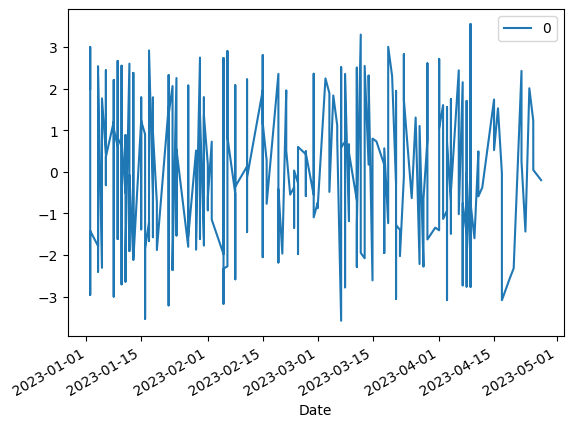

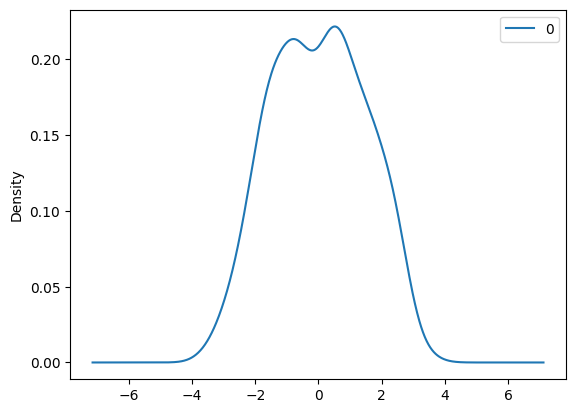

                0
count  551.000000
mean     0.007729
std      1.489022
min     -3.580880
25%     -1.175077
50%      0.033737
75%      1.176615
max      3.555668


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA (series, order=(5,1,0))
model_fit = model.fit()
print(model_fit.summary())

# plot residual errors
residuals = pd.DataFrame(model_fit.resid)
residuals.plot()
plt.show()
residuals.plot(kind='kde')
plt.show()
print (residuals.describe())

**so sánh MSE, MAE, .... => Linear**

In [ ]:
X_train.to_csv('X_train.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv')['Sales']
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv')['Sales']

model = LinearRegression()
model.fit(X_train, y_train)

train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_results = pd.DataFrame({'Item': X_train['Item'], 'Predicted_Sales': train_predictions})
test_results = pd.DataFrame({'Item': X_test['Item'], 'Predicted_Sales': test_predictions})

print("Train:")
print(train_results.head())
print("\nTest:")
print(test_results.head())

train_results.to_csv('train_predictions.csv', index=False)
test_results.to_csv('test_predictions.csv', index=False)


Train:
   Item  Predicted_Sales
0     1         0.507417
1     0         0.522542
2     1         0.494154
3     0         0.518734
4     2         0.477209

Test:
   Item  Predicted_Sales
0     1         0.494224
1     3         0.464008
2     1         0.483608
3     1         0.498153
4     1         0.511765
